In [2]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

In [ ]:
PROJECT_ROOT = Path.cwd().parent

IMAGE_DIR = PROJECT_ROOT / "data" / "raw" / "Images"
CAPTION_FILE = (PROJECT_ROOT/ "data"/ "raw"/ "annotations"/ "Flickr8k.token.txt")

print("Image directory:", IMAGE_DIR)
print("Caption file:", CAPTION_FILE)

Image directory: y:\Nlp\Image Caption Generator\data\raw\Images
Caption file: y:\Nlp\Image Caption Generator\data\raw\annotations\Flickr8k.token.txt


In [6]:
captions_df = pd.read_csv(CAPTION_FILE, sep="\t", header=None, names=["caption_id", "caption"])

print(captions_df.head())
print("Shape:", captions_df.shape)
print("Columns:", captions_df.columns.tolist())

                    caption_id  \
0  1000268201_693b08cb0e.jpg#0   
1  1000268201_693b08cb0e.jpg#1   
2  1000268201_693b08cb0e.jpg#2   
3  1000268201_693b08cb0e.jpg#3   
4  1000268201_693b08cb0e.jpg#4   

                                             caption  
0  A child in a pink dress is climbing up a set o...  
1              A girl going into a wooden building .  
2   A little girl climbing into a wooden playhouse .  
3  A little girl climbing the stairs to her playh...  
4  A little girl in a pink dress going into a woo...  
Shape: (40460, 2)
Columns: ['caption_id', 'caption']


In [8]:
captions_df[["image", "caption_number"]] = (captions_df["caption_id"].str.rsplit("#", n=1, expand=True))

captions_df["caption_number"] = captions_df["caption_number"].astype(int)

captions_df = captions_df[["image", "caption_number", "caption"]]

print(captions_df.head())

KeyError: 'caption_id'

In [9]:
image_files = list(IMAGE_DIR.glob("*.jpg"))

print("Number of image files:", len(image_files))
print("Number of unique captioned images:", captions_df["image"].nunique())
print("Missing captions:", captions_df["caption"].isna().sum())

Number of image files: 8091
Number of unique captioned images: 8092
Missing captions: 0


In [10]:
captions_per_image = captions_df.groupby("image").size()

print(captions_per_image.describe())
print(captions_per_image.value_counts())

count    8092.0
mean        5.0
std         0.0
min         5.0
25%         5.0
50%         5.0
75%         5.0
max         5.0
dtype: float64
5    8092
Name: count, dtype: int64


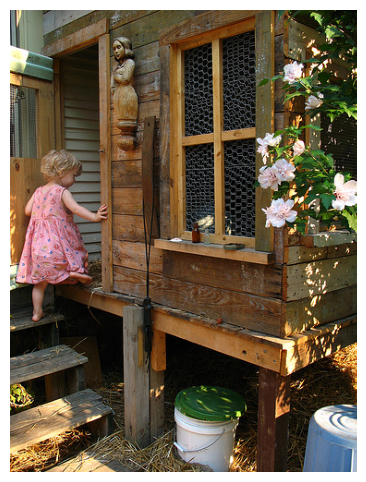

1. A child in a pink dress is climbing up a set of stairs in an entry way .
2. A girl going into a wooden building .
3. A little girl climbing into a wooden playhouse .
4. A little girl climbing the stairs to her playhouse .
5. A little girl in a pink dress going into a wooden cabin .


In [11]:
sample_image_name = captions_df["image"].iloc[0]
sample_image_path = IMAGE_DIR / sample_image_name

image = Image.open(sample_image_path)

plt.figure(figsize=(8, 6))
plt.imshow(image)
plt.axis("off")
plt.show()

sample_captions = captions_df.loc[
    captions_df["image"] == sample_image_name,
    "caption"
]

for number, caption in enumerate(sample_captions, start=1):
    print(f"{number}. {caption}")

In [12]:
image_names = {path.name for path in IMAGE_DIR.glob("*.jpg")}
captioned_image_names = set(captions_df["image"])

missing_images = sorted(captioned_image_names - image_names)
extra_images = sorted(image_names - captioned_image_names)

print("Captioned images missing from folder:", missing_images)
print("Images without captions:", extra_images)

Captioned images missing from folder: ['2258277193_586949ec62.jpg.1']
Images without captions: []


In [13]:
ANNOTATION_DIR = PROJECT_ROOT / "data" / "raw" / "annotations"

split_files = {
    "train": "Flickr_8k.trainImages.txt",
    "validation": "Flickr_8k.devImages.txt",
    "test": "Flickr_8k.testImages.txt",
}

for split_name, filename in split_files.items():
    split_images = set(
        pd.read_csv(
            ANNOTATION_DIR / filename,
            header=None
        )[0].str.strip()
    )

    overlap = split_images.intersection(missing_images)
    print(f"{split_name}: {overlap}")

train: set()
validation: set()
test: set()


In [14]:
captions_df = captions_df[
    ~captions_df["image"].isin(missing_images)
].reset_index(drop=True)

In [15]:
print("Caption rows after filtering:", len(captions_df))
print("Unique usable images:", captions_df["image"].nunique())

Caption rows after filtering: 40455
Unique usable images: 8091


In [16]:
import torch

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print(
        "GPU memory:",
        round(
            torch.cuda.get_device_properties(0).total_memory / 1024**3,
            2
        ),
        "GB"
    )

CUDA available: False
